In [1]:
import pickle
import datetime
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import torch
from copy import deepcopy as dc
import os
from create_agents import create_flappy_agent, create_lunarlander_agent, create_robot_agent
import gymnasium as gym
import os
import re

## Overview
Pull fNIRS data file from dataset. Then align the neural data with the task data.

Add the labels, and then save it the file.

### Extract PID and Task Condition

In [2]:
# PID
pid = 10

#Task and Condition
condition = "RP"

### Find Files for Participant Conditions

In [3]:
pid = str("0" + str(pid) + "_")

def find_files(participant_id, condition):

    source_folder_1 = "/Users/juliasantaniello/Desktop/fNIRS-2-RL/Experiment/ParticipantData/TaskData"
    source_folder_2 = "/Users/juliasantaniello/Desktop/fNIRS-2-RL/Experiment/ParticipantData/fNIRS/FilteredData"

    def find_matching_files_with_paths(folder, pid, condition):
        return [
            os.path.join(folder, file)
            for file in os.listdir(folder)
            if pid in file and condition in file]

    matching_files_folder1 = find_matching_files_with_paths(source_folder_1, participant_id, condition)
    matching_files_folder2 = find_matching_files_with_paths(source_folder_2, participant_id, condition)

    all_matching_files = {
        "Folder 1": matching_files_folder1,
        "Folder 2": matching_files_folder2
    }

    for folder, files in all_matching_files.items():
        print(f"\nMatching files in {folder}:")
        if files:
            for file in files:
                if file.endswith('.pickle'):
                    df_pickle = file
                if file.endswith('.csv'):
                    df_neural = file
                print(file)
        else:
            print("No matching files found.")

    if condition[0] == "L":
        policy_path = 'policies/LunarLanderPolicies'
    if condition[0] == "F":
        policy_path = 'policies/FlappyBirdPolicies'
    if condition[0] == "R":
        policy_path = 'policies/RobotPolicies'

    return df_pickle, df_neural, policy_path

In [4]:
def policy_set():
    if condition[0] == "L":
        policy_set = {
            0: create_lunarlander_agent("policies/LunarLanderPolicies/LLPolicy100_1"),
            1: create_lunarlander_agent("policies/LunarLanderPolicies/LLPolicy100"),
            2: create_lunarlander_agent("policies/LunarLanderPolicies/LLPolicy98"),
            3: create_lunarlander_agent("policies/LunarLanderPolicies/LLPolicy98_1"),
            4: create_lunarlander_agent("policies/LunarLanderPolicies/LLPolicy98_2"),
            5: create_lunarlander_agent("policies/LunarLanderPolicies/LLPolicy98_3"),
            6: create_lunarlander_agent("policies/LunarLanderPolicies/LLPolicy96"),
            7: create_lunarlander_agent("policies/LunarLanderPolicies/LLPolicy96_1"),
            8: create_lunarlander_agent("policies/LunarLanderPolicies/LLPolicy96_2"),
            9: create_lunarlander_agent("policies/LunarLanderPolicies/LLPolicy96_3")
        }
    if condition[0] == "R":
        policy_set = {
            0: create_robot_agent("policies/RobotPolicies/FetchPickAndPlace1.pth"),
            1: create_robot_agent("policies/RobotPolicies/FetchPickAndPlace2.pth"),
            2: create_robot_agent("policies/RobotPolicies/FetchPickAndPlace3.pth"),
            3: create_robot_agent("policies/RobotPolicies/FetchPickAndPlace4.pth"),
            4: create_robot_agent("policies/RobotPolicies/FetchPickAndPlace5.pth"),
            5: create_robot_agent("policies/RobotPolicies/FetchPickAndPlace6.pth"),
            6: create_robot_agent("policies/RobotPolicies/FetchPickAndPlace7.pth"),
            7: create_robot_agent("policies/RobotPolicies/FetchPickAndPlace8.pth"),
            8: create_robot_agent("policies/RobotPolicies/FetchPickAndPlace9.pth"),
            9: create_robot_agent("policies/RobotPolicies/FetchPickAndPlace10.pth"),
        }
        
    if condition[0] == "F":
        policy_set = {
            0: create_flappy_agent("policies/FlappyBirdPolicies/FlappyBirdOptimalPolicy1"),
            1: create_flappy_agent("policies/FlappyBirdPolicies/FlappyBirdOptimalPolicy2"),
            2: create_flappy_agent("policies/FlappyBirdPolicies/FlappyBirdOptimalPolicy3"),
            3: create_flappy_agent("policies/FlappyBirdPolicies/FlappyBirdOptimalPolicy4"),
            4: create_flappy_agent("policies/FlappyBirdPolicies/FlappyBirdOptimalPolicy5"),
            5: create_flappy_agent("policies/FlappyBirdPolicies/FlappyBirdOptimalPolicy6"),
            6: create_flappy_agent("policies/FlappyBirdPolicies/FlappyBirdOptimalPolicy7"),
            7: create_flappy_agent("policies/FlappyBirdPolicies/FlappyBirdOptimalPolicy8"),
            8: create_flappy_agent("policies/FlappyBirdPolicies/FlappyBirdOptimalPolicy9"),
            9: create_flappy_agent("policies/FlappyBirdPolicies/FlappyBirdOptimalPolicy10"),

        }

    return policy_set

In [5]:
# Function to extract PID and what condition it is from filename
def extract_pid_and_suffix(filename):
    pid_match = re.search(r'(\d{3})', filename)
    suffix_match = re.search(r'_(LP|LW|FP|FW|RP|RW)_', filename)
    pid = pid_match.group(1) if pid_match else None
    suffix = suffix_match.group(1) if suffix_match else None
    return pid, suffix

In [6]:
demo_dfs, neural_dfs = [], []

# Load data files
df_pickle, df_neural, policy_path = find_files(pid, condition)
df_pickle = open(df_pickle, 'rb')
df_dict = dict(pickle.load(df_pickle))
df = pd.DataFrame(df_dict)
demo_dfs.append(df)

fnirs_df = pd.read_csv(df_neural)
neural_dfs.append(fnirs_df)


Matching files in Folder 1:
/Users/juliasantaniello/Desktop/fNIRS-2-RL/Experiment/ParticipantData/TaskData/010_RP_091824.pickle

Matching files in Folder 2:
/Users/juliasantaniello/Desktop/fNIRS-2-RL/Experiment/ParticipantData/fNIRS/FilteredData/010_RP_processed.csv


In [7]:
#Neural features
all_neural_features = ['L_O_DSphi', 'L_D_DSphi', 'R_D_DSphi', 'R_O_DSphi', 'L_O_DSI', 'R_D_DSI', 'R_O_DSI', 'L_D_DSI']
phasic_neural_features = ['L_O_DSphi', 'L_D_DSphi', 'R_D_DSphi', 'R_O_DSphi']
intensity_neural_features = ['L_O_DSI', 'R_D_DSI', 'R_O_DSI', 'L_D_DSI']

#Labels
labels = ['continuous_optimal', 'binary_optimal', 'discrete_optimal']

### Classifier Functions:
#### Compute Discounted Rewards

In [8]:
def compute_discounted_rewards(rewards, gamma):
    discounted_rewards = np.zeros_like(rewards, dtype=np.float64)
    cumulative_sum = 0.0
    
    for t in (range(len(rewards))):
        if rewards[t] == None:
            continue
        cumulative_sum = rewards[t] + gamma * cumulative_sum
        discounted_rewards[t] = cumulative_sum

    return discounted_rewards

### Align Datasets

In [9]:
# def change_neural_timestamps(neural_df, demo_df):
#     neural_start_time = neural_df["time"][0]
#     neural_timestamp = datetime.strptime(neural_start_time[0:25], "%Y-%m-%d %H:%M:%S.%f")

#     print("Neural Start Time", demo_df["floatTimestamps"])
#     if abs(demo_df["floatTimestamps"][1] - demo_df["floatTimestamps"][0]) > 15:
#         demo_start_time = demo_df["floatTimestamps"][1]
#     else:
#         demo_start_time = demo_df["floatTimestamps"][0]
        
#     diff = demo_start_time - neural_timestamp.timestamp()
#     print("Demo Start Time", datetime.fromtimestamp(demo_start_time))

#     neural_df[['dateTimestamps', 'floatTimestamps']] = neural_df['time'].apply(lambda x: pd.Series(add_time(x, diff)))
#     neural_df["L_D_DSI"].size
#     neural_df.drop(columns=['Unnamed: 0', 'time'], axis=0)

#     return neural_df, demo_df

# def add_time(timestamp_str, diff):
#     timestamp_obj = datetime.strptime(timestamp_str[:-3], "%Y-%m-%d %H:%M:%S.%f")
#     new_timestamp_obj = timestamp_obj + timedelta(seconds=diff)
#     new_timestamp_str = new_timestamp_obj.strftime("%Y-%m-%d %H:%M:%S.%f") #+ timestamp_obj[-3:]
#     new_float_timestamp = new_timestamp_obj.timestamp()

#     return new_timestamp_str, new_float_timestamp

In [10]:
timestamps = pd.to_datetime(neural_dfs[0]["time"].str[:25], format="%Y-%m-%d %H:%M:%S.%f")
timestamps


0     2024-09-18 22:43:16.591760
1     2024-09-18 22:43:16.654240
2     2024-09-18 22:43:16.734980
3     2024-09-18 22:43:16.803730
4     2024-09-18 22:43:16.871570
                 ...            
914   2024-09-18 22:46:11.567310
915   2024-09-18 22:46:11.629800
916   2024-09-18 22:46:11.706970
917   2024-09-18 22:46:12.644720
918   2024-09-18 22:46:12.706720
Name: time, Length: 919, dtype: datetime64[ns]

### Merge Datasets

In [11]:
def merge_dfs(demo_df, neural_df, column_of_interest, time_window_seconds=0.1):
    # print(demo_df.columns)
    demo_df['timestamps'] = pd.to_datetime(demo_df['floatTimestamps'], unit='s')
    neural_df['timestamps'] = pd.to_datetime(neural_df["time"].str[:25], format="%Y-%m-%d %H:%M:%S.%f")

    print("Demo Data Length: ", len(demo_df['timestamps']))
    print("Neural Data Length: ", len(neural_df['timestamps']))
    print("Last Neural Timestamp: ", neural_df["timestamps"][len(neural_df['timestamps'])-1])

    merged_records = []

    for i, row in neural_df.iterrows():
        timestamp = row['timestamps']

        time_window = pd.Timedelta(seconds=time_window_seconds)
        demo_window = demo_df[
            (demo_df['timestamps'] >= timestamp - time_window) &
            (demo_df['timestamps'] <= timestamp + time_window)
        ]

        if not demo_window.empty:
            # Find the row with the maximum value in the specified column
            max_row = demo_window.loc[demo_window[column_of_interest].idxmax()]

            #Append the merged data
            merged_row = {**row.to_dict(), **max_row.to_dict()}
            merged_records.append(merged_row)

    # Convert the list of merged records to a DataFrame
    merged_df = pd.DataFrame(merged_records)

    return merged_df

### Create new Dictionary

In [12]:
def create_time_dict(num, demo_dict, gamma):
    
    new_dict = {'floatTimestamps':[],
                'dateTimestamps': [],
                'episode': [],
                'states': [],
                'actions': [],
                'rewards':[],
                'chosen_actions': [],
                'optimal_actions': [],
                'desired_goal': [],
                'achieved_goal': [],
                'numDemonstrations': [],
                'steps': [],
                'seed': [],
    }
    
    for i in range(num):
        for j in range(len(demo_dict[i]['actions'])):
            new_dict['floatTimestamps'].append(demo_dict[i]["floatTimestamps"][j])
            new_dict['dateTimestamps'].append(demo_dict[i]["dateTimestamps"][j])
            new_dict['rewards'].append(demo_dict[i]["rewards"][j])

            new_dict['chosen_actions'].append(demo_dict[i]["chosen_actions"][j])
            new_dict['optimal_actions'].append(demo_dict[i]["optimal_actions"][j])
         
            new_dict['actions'].append(demo_dict[i]["actions"][j])
            new_dict['episode'].append(demo_dict[i]['episode'])
            new_dict['steps'].append(demo_dict[i]['steps'])
            new_dict['states'].append(demo_dict[i]["states"][j])

            new_dict['numDemonstrations'].append(num)
            new_dict['seed'].append(demo_dict[i]["seed"])

            if condition[0]=="R":
                new_dict["desired_goal"].append((demo_dict[i]["desired_goal"]))
                new_dict['achieved_goal'].append(demo_dict[i]["achieved_goal"][j])

    return new_dict

### Util Functions

In [13]:
def softmax(values):
    if values is None:
        return 0
 
    exp_values = np.exp(values, dtype=np.longdouble)
    exp_values_sum = np.sum(exp_values)
    vals = np.asarray(exp_values/exp_values_sum, dtype=np.float64)

    return vals

def from_tensor(x):
    try:
        x = x[0].detach().cpu().numpy()
        return softmax(x)
    except:
        return None

### Optimality Metric/Label Helper Functions

In [128]:
def KL_regression_labels(P, Q):
    from scipy.special import rel_entr

    if P is None or Q is None:
        return 0

    return sum(rel_entr(P, Q))

def euclideanDist(vector1, vector2):
    if vector1 is None or vector2 is None:
        return 0
    
    return np.linalg.norm(vector1 - vector2)

def MSE(vector1, vector2):
    if vector1 is None or vector2 is None:
        return 0
    
    return np.mean((vector1 - vector2) ** 2)

def cosine_similarity(vector1, vector2):
    if vector1 is None or vector2 is None:
        return 0
    
    return np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))

def game_result(r, condition, conditional = None):
    print(r, condition, conditional)
    if condition[0] == "L":
        if r > 75:
            return 0, 0
        elif r < -10:
            return 1, 2
        else:
            return 1, 1
        
    if condition[0] == "F":
        if r < 100:
            return 1, 2
        elif r < 200:
            return 1, 1
        else:
            return 0, 0
        
    if condition == "RW":
        if r > -1.0:
            return 0, 0
        elif conditional > 200:
            return 1, 2
        else:
            return 1, 1
    if condition == "RP":
        if r == -0.0 and conditional < 100:
            return 0, 0
        elif r == -0.0 and conditional > 100:
            return 1, 1
        else:
            return 1, 2

def add_binary_labels(df, condition=None):
    from math import dist

    # Initialize new columns if they don't exist
    df["binary_optimal"] = 0
    df["discrete_optimal"] = 0
    

    for episode, group in df.groupby("episode"):
        conditional = group["rewards"].iloc[-1]
        reward = group["rewards"].iloc[-1]
        chosen_actions = group["actions"]
        optimal_actions = group["optimal_actions"]

        if condition[0] == "F":
            conditional = len(group)
            # print(conditional)
        elif condition[0] == "R":
            reward = conditional
            conditional, distance = 0, 0
            for o, a in zip(optimal_actions, chosen_actions):
                if a is None or o is None:
                    continue
                for i, ii in zip(a, o):
                    distance = abs(i-ii)

                conditional += distance

        group.head(1)

        # print(reward, conditional, condition)
        print("Reward", reward, "Conditional", conditional)
        binary, discrete = game_result(reward, condition, conditional)
        print("Binary", binary, "Discrete", discrete)
        
        # print(binary, discrete)

        max_index = group["continuous_optimal"].idxmax()

        if episode == 2:
            print(max_index, conditional, binary, discrete)

        df.loc[group.index[group.index >= max_index], "binary_optimal"] = binary
        df.loc[group.index[group.index >= max_index], "discrete_optimal"] = discrete

    return df

def robot_optimality_selection(policy_set, states, chosen_action, goal):
    error_values = []

    for i, state in enumerate(states):
        policy_errors = []
        for policy_index in range(len(policy_set)):
            
            agent = policy_set[policy_index]

            optimal_action = agent.choose_action(state, goal[i], train_mode=False)

            error = euclideanDist(chosen_action[i], optimal_action)
        
            policy_errors.append(error)

        error_values.append(np.mean(policy_errors))
    
    # print("Continuous Optimality Error", len(error_values), error_values)

    return error_values


def game_optimality_selection(policy_set, states, chosen_action_values, goal=None):
    prob_set = []
    all_values = []

    for policy_index in range(len(policy_set)):
        for i, state in enumerate(states):
            agent = policy_set[policy_index]

            _, optimal_action_values = agent.chooseAction(state, 0.0)
            optimal_action_values = softmax(from_tensor(optimal_action_values[i]))
            all_values.append(optimal_action_values)

            error = KL_regression_labels(chosen_action_values[i], optimal_action_values)
        
            prob_set.append(error)

        prob_set_mean = np.mean(np.asarray(prob_set))

    return prob_set

def add_continuous_labels(policy_set, chosen_action_values, state, desired_goal=None):
    if condition[0] == "L" or condition[0] == "F":
        return game_optimality_selection(policy_set=policy_set, states=state, chosen_action_values=chosen_action_values, goal=None)
    else:
        return robot_optimality_selection(policy_set=policy_set, states=state, chosen_action=chosen_action_values, goal=desired_goal)

### Computing Labels for Dataset

In [129]:
def add_labels_to_df(df, binary_labels:bool = False, continuous_labels:bool= False, discrete_labels:bool = False):  
    if continuous_labels:
        p_set = policy_set()
        continuous_labels_for_df = add_continuous_labels(p_set, df["chosen_actions"], df["states"], df["desired_goal"])
        df["continuous_optimal"] = continuous_labels_for_df
    if binary_labels:
        df = add_binary_labels(df, condition=condition) 
    return df

def drop_na(df):
    df = df.dropna()
    nans_per_column = df.isna().sum()
    # print("NaNs Per Column After Dropping: ", nans_per_column)
    return df

### Main Function for Labeling Dataset

In [130]:
for i, df in enumerate(demo_dfs):
    num = df[0]["numDemonstrations"]

    df2 = create_time_dict(num, df, gamma=0.99)
    robot = True if df[0]['environment'][0] == "R" else False

    demo_df = pd.DataFrame(df2)
    # print(demo_df)
    demo_df = drop_na(demo_df)
    demo_df = demo_df.reset_index(drop=True)
    # dist=0
    # for action, optimal_action in zip(demo_df["actions"], demo_df["optimal_actions"]):
    #     for i, ii in zip(action, optimal_action):
    #         dist += abs(i-ii)

    # print(dist)
    add_labels_to_df(
        demo_df,
        binary_labels=True,
        continuous_labels=True
    )

    dd = dc(demo_df)
    print(dd.columns)

    merged_df = merge_dfs(demo_df=dd, neural_df=neural_dfs[i], column_of_interest="continuous_optimal", time_window_seconds=0.4)
    merged_df = drop_na(merged_df.drop(index=0, axis=0))

Reward -0.0 Conditional 0.034111656714230776
-0.0 RP 0.034111656714230776
Binary 0 Discrete 0
Reward -1.0 Conditional 149.06206872261828
-1.0 RP 149.06206872261828
Binary 1 Discrete 2
Reward -1.0 Conditional 183.65080653503537
-1.0 RP 183.65080653503537
Binary 1 Discrete 2
531 183.65080653503537 1 2
Reward -0.0 Conditional 112.96188153792173
-0.0 RP 112.96188153792173
Binary 1 Discrete 1
Reward -0.0 Conditional 97.3528623341117
-0.0 RP 97.3528623341117
Binary 0 Discrete 0
Reward -0.0 Conditional 47.74937483808026
-0.0 RP 47.74937483808026
Binary 0 Discrete 0
Reward -0.0 Conditional 112.65872025652789
-0.0 RP 112.65872025652789
Binary 1 Discrete 1
Reward -0.0 Conditional 70.31966913305223
-0.0 RP 70.31966913305223
Binary 0 Discrete 0
Index(['floatTimestamps', 'dateTimestamps', 'episode', 'states', 'actions',
       'rewards', 'chosen_actions', 'optimal_actions', 'desired_goal',
       'achieved_goal', 'numDemonstrations', 'steps', 'seed',
       'continuous_optimal', 'binary_optimal', '

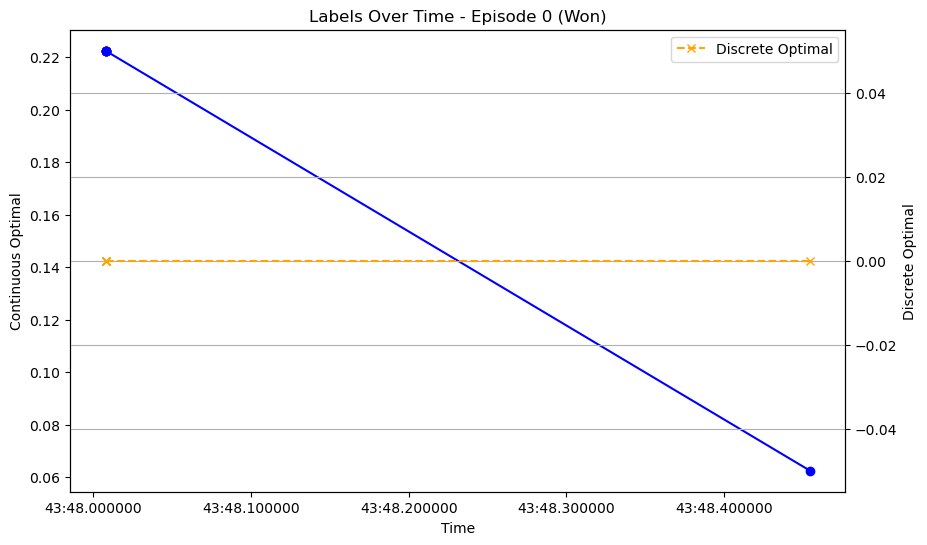

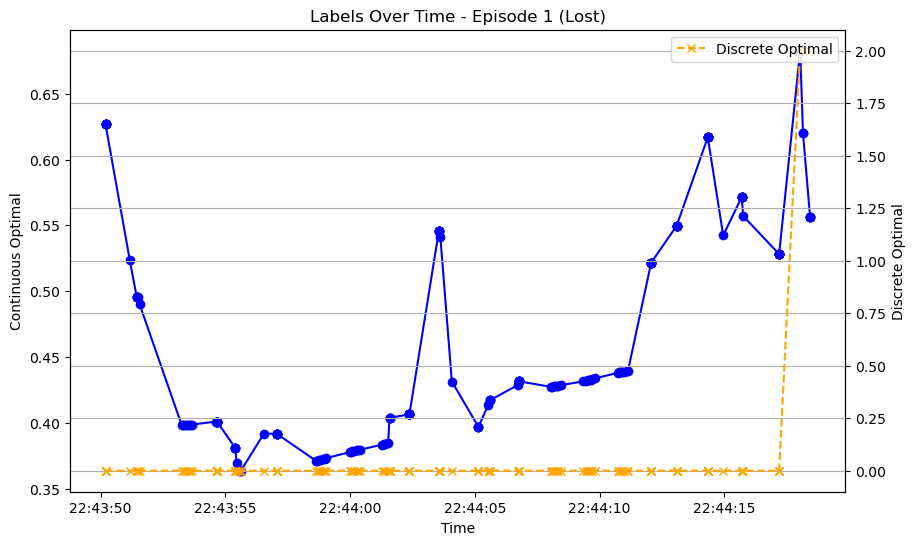

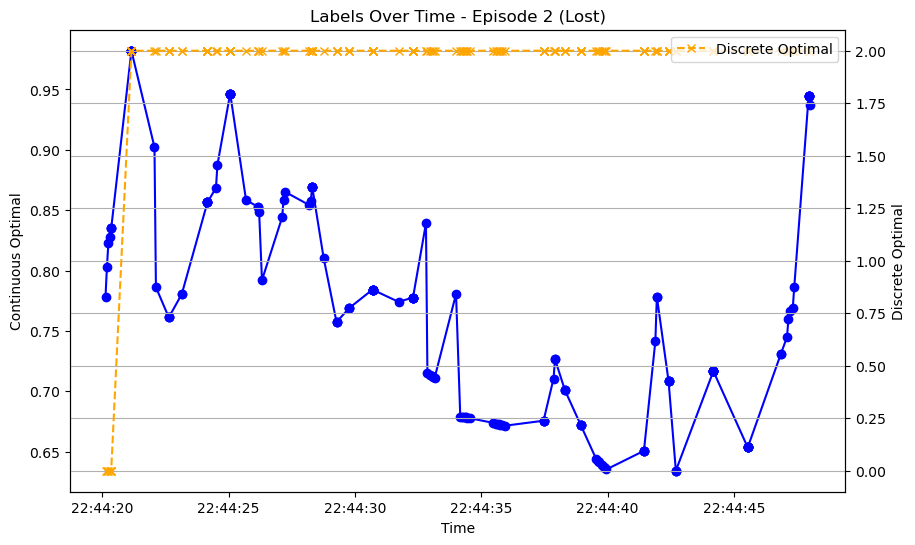

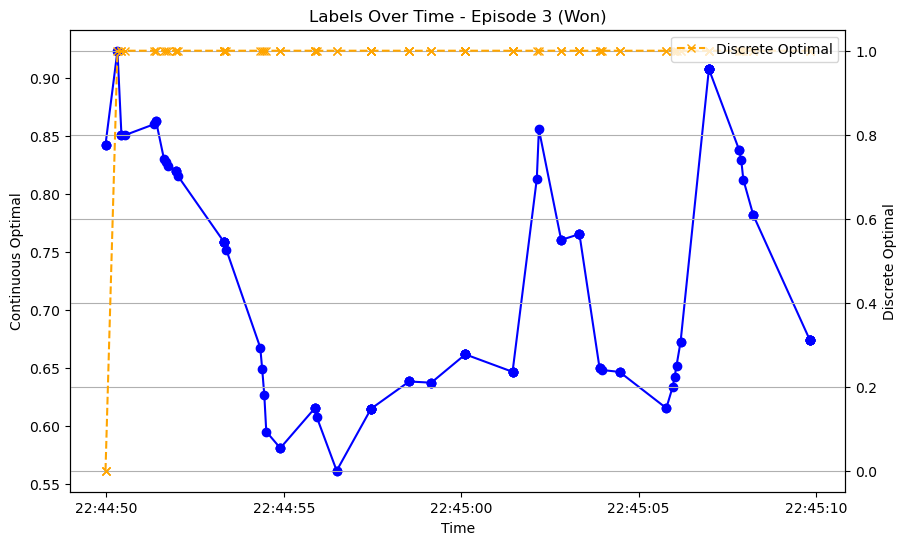

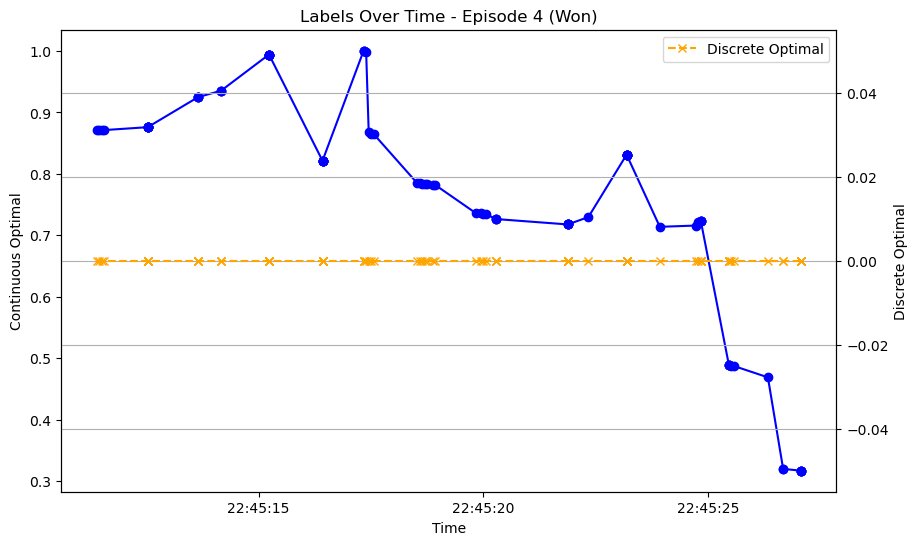

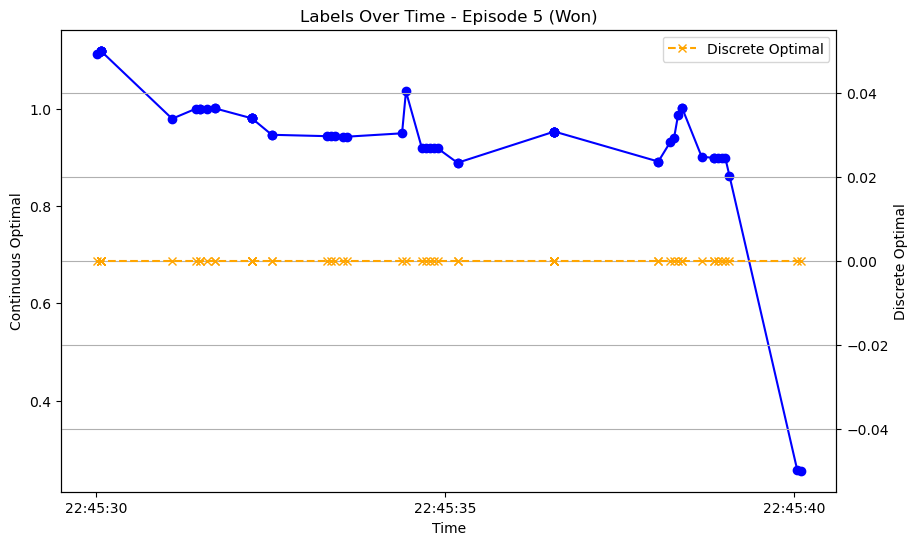

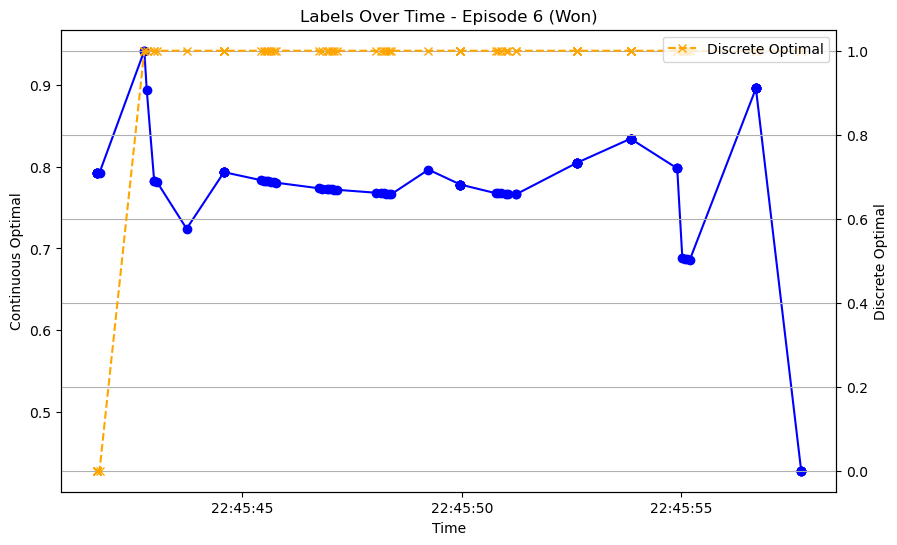

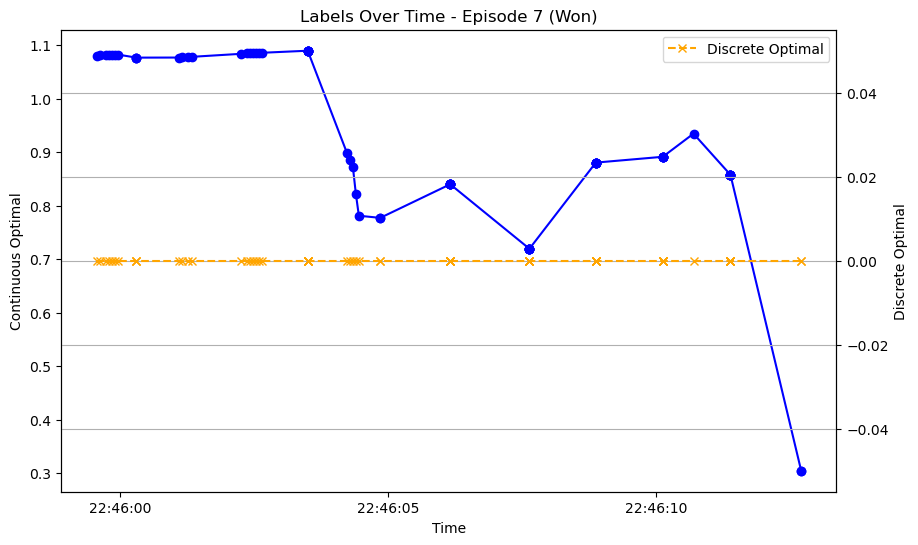

In [147]:
import matplotlib.pyplot as plt

# Group by episodes
grouped_by_episode = merged_df.groupby("episode")

# Create a plot for each episode
for episode, group in grouped_by_episode:
    # Check if the episode was won
    episode_won = group["rewards"].iloc[-1] == -0.0
    win_status = "Won" if episode_won else "Lost"
    
    plt.figure(figsize=(10, 6))
    
    # Plot continuous optimal labels
    plt.plot(group["timestamps"], group["continuous_optimal"], marker='o', label='Continuous Optimal', color='blue')
    plt.xlabel("Time")
    plt.ylabel("Continuous Optimal")
    
    # Add secondary y-axis for discrete labels
    ax2 = plt.gca().twinx()
    ax2.plot(group["timestamps"], group["discrete_optimal"], marker='x', label='Discrete Optimal', color='orange', linestyle='--')
    ax2.set_ylabel("Discrete Optimal")
    
    # Add title and legend
    plt.title(f"Labels Over Time - Episode {episode} ({win_status})")
    plt.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.grid(True)
    plt.show()


In [146]:
merged_df.to_csv("{}{}_LabeledData.csv".format(pid, condition))